# 零基础实战机器学习

## 第16讲 会员流失情况评估

作者 黄佳

极客时间专栏链接：https://time.geekbang.org/column/intro/438


问题：判断易速鲜花会员的是否会流失情况

易速鲜花公司拥有多年的会员记录，以及会员停止续费的情况。

通过逻辑回归和神经网络等机器学习模型，我们可以判断出客户是否离开，这是一个典型的的二元分类问题。

这一讲我们集中介绍分类问题的评估指标：混淆矩阵，精确率，召回率，F1分数，ROC曲线和AUC。


## 数据的读入和预处理

In [1]:
# 导入数据包
import numpy as np # 
import pandas as pd #
import matplotlib.pyplot as plt #

In [7]:
df_member = pd.read_csv('易速鲜花会员留存.csv')
df_member

用户码       0
性别        0
玫瑰套餐      0
紫罗兰套餐     0
郁金香套餐     0
百合套餐      0
康乃馨套餐     0
胡姬花套餐     0
生日套餐      0
情人节套餐     0
会员卡类型     0
入会月数      0
会费支付方式    0
平均月消费     0
总消费       0
已停付会费     0
dtype: int64

### 数据清洗

In [9]:
#把总消费字段转换成数值字段
df_member['总消费'] = pd.to_numeric(df_member['总消费'], errors='coerce')
df_member['总消费'].fillna(0, inplace=True)
df_member.isna().sum()

C:\Users\rossliao\AppData\Local\Temp\ipykernel_9540\2270689222.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_member['总消费'].fillna(0, inplace=True)


用户码       0
性别        0
玫瑰套餐      0
紫罗兰套餐     0
郁金香套餐     0
百合套餐      0
康乃馨套餐     0
胡姬花套餐     0
生日套餐      0
情人节套餐     0
会员卡类型     0
入会月数      0
会费支付方式    0
平均月消费     0
总消费       0
已停付会费     0
dtype: int64

### 数据可视化

C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26159 (\N{CJK UNIFIED IDEOGRAPH-662F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21542 (\N{CJK UNIFIED IDEOGRAPH-5426}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27969 (\N{CJK UNIFIED IDEOGRAPH-6D41}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\rossliao\AppData\Local\

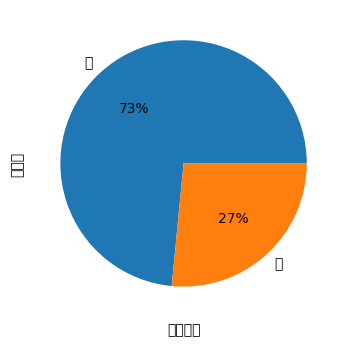

In [10]:
plt.figure(figsize=(6,4))
ax = df_member.groupby('已停付会费').count()['用户码'].plot.pie(autopct='%1.0f%%') #饼图
plt.xlabel('是否流失')
plt.show() #显示

### 特征工程

In [11]:
df_member['已停付会费'].replace(to_replace='是', value=1, inplace=True) #流失-1
df_member['已停付会费'].replace(to_replace='否',  value=0, inplace=True) #未流失-0

C:\Users\rossliao\AppData\Local\Temp\ipykernel_9540\1263449143.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_member['已停付会费'].replace(to_replace='是', value=1, inplace=True) #流失-1
C:\Users\rossliao\AppData\Local\Temp\ipykernel_9540\1263449143.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always 

In [12]:
df_member['性别'].replace(to_replace='女', value=0, inplace=True) #女生-0
df_member['性别'].replace(to_replace='男', value=1, inplace=True) #男生-1

C:\Users\rossliao\AppData\Local\Temp\ipykernel_9540\2596809050.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_member['性别'].replace(to_replace='女', value=0, inplace=True) #女生-0
C:\Users\rossliao\AppData\Local\Temp\ipykernel_9540\2596809050.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always beh

In [13]:
# 字段中'Yes' or 'No'转换成为模型可以读取的数值,（布尔型数据，也是数值数据）
binary_features = ['玫瑰套餐', '紫罗兰套餐', '郁金香套餐', '百合套餐', '康乃馨套餐', '胡姬花套餐', 
                   '生日套餐','情人节套餐']
for field in binary_features:
    df_member[field] = df_member[field] == '是'

In [14]:
df_member

,用户码,性别,玫瑰套餐,紫罗兰套餐,郁金香套餐,百合套餐,康乃馨套餐,胡姬花套餐,生日套餐,情人节套餐,会员卡类型,入会月数,会费支付方式,平均月消费,总消费,已停付会费
0,1,0,True,True,False,True,False,True,True,False,年卡,9,手工转账,65.60,593.30,0
1,2,1,False,False,False,False,False,False,False,True,月卡,9,手工转账,59.90,542.40,0
2,3,1,False,False,False,False,True,False,False,False,月卡,4,就餐时付费,73.90,280.85,1
3,4,1,True,False,False,True,True,False,True,True,月卡,13,就餐时付费,98.00,1237.85,1
4,5,0,False,True,False,False,False,True,True,True,月卡,9,花呗付款,69.40,571.45,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7039,0,False,False,True,False,False,True,False,False,年卡,13,手工转账,55.15,742.90,0
7039,7040,1,False,False,False,True,False,False,False,False,月卡,2,手工转账,50.30,92.75,0
7040,7041,1,True,False,False,False,False,False,False,True,月卡,22,就餐时付费,85.10,1873.70,1
7041,7042,1,True,True,True,False,True,True,False,True,双年卡,67,手工转账,67.85,4627.65,0


### 数据整理
先做数据整理工作，把每个数据字段都转换为可以处理的字段

In [15]:
# One hot encode 分类字段
category_features = ['会员卡类型', '会费支付方式']
df_member = pd.get_dummies(df_member, drop_first=True, columns=category_features)
df_member

,用户码,性别,玫瑰套餐,紫罗兰套餐,郁金香套餐,百合套餐,康乃馨套餐,胡姬花套餐,生日套餐,情人节套餐,入会月数,平均月消费,总消费,已停付会费,会员卡类型_年卡,会员卡类型_月卡,会费支付方式_微信自动扣款,会费支付方式_手工转账,会费支付方式_花呗付款
0,1,0,True,True,False,True,False,True,True,False,9,65.60,593.30,0,True,False,False,True,False
1,2,1,False,False,False,False,False,False,False,True,9,59.90,542.40,0,False,True,False,True,False
2,3,1,False,False,False,False,True,False,False,False,4,73.90,280.85,1,False,True,False,False,False
3,4,1,True,False,False,True,True,False,True,True,13,98.00,1237.85,1,False,True,False,False,False
4,5,0,False,True,False,False,False,True,True,True,9,69.40,571.45,0,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,7039,0,False,False,True,False,False,True,False,False,13,55.15,742.90,0,True,False,False,True,False
7039,7040,1,False,False,False,True,False,False,False,False,2,50.30,92.75,0,False,True,False,True,False
7040,7041,1,True,False,False,False,False,False,False,True,22,85.10,1873.70,1,False,True,False,False,False
7041,7042,1,True,True,True,False,True,True,False,True,67,67.85,4627.65,0,False,False,False,True,False


### 构建特征集和标签集

In [46]:
X = df_member.drop(['用户码','已停付会费'], axis = 1) # 构建特征集，用户吗字段属于无用特征
y = df_member.已停付会费.values # 构建标签集

### 拆分数据集

In [47]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2, random_state = 4)

## 选择算法

这里我们比较逻辑回归和神经网络两种算法

### 逻辑回归模型

#### 导入模型

In [48]:
from sklearn.linear_model import LogisticRegression #导入逻辑回归模型
logreg = LogisticRegression() # logreg,就代表是逻辑回归模型

#### 训练机器

In [49]:
logreg.fit(X_train,y_train) # fit,就相当于是梯度下降

C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

#### 评估分数

In [50]:
print("SK-learn逻辑回归预测准确率{:.2f}%".format(logreg.score(X_test,y_test)*100))

SK-learn逻辑回归预测准确率78.57%


#### 预测结果

In [51]:
y_pred_logreg = logreg.predict(X_test)
print("逻辑回归对测试集第一个用户的预测结果", y_pred_logreg[0])

逻辑回归对测试集第一个用户的预测结果 0


#### 混淆矩阵

In [52]:
from sklearn.metrics import confusion_matrix # 导入混淆矩阵
import seaborn as sns #导入seaborn画图工具箱
def show_matrix(y_test, y_pred, label): # 定义一个函数显示混淆矩阵
    cm = confusion_matrix(y_test,y_pred) # 调用混淆矩阵
    plt.title(label) # 标题
    sns.heatmap(cm,annot=True,cmap="Blues",fmt="d",cbar=False) # 热力图设定
    plt.show() # 显示混淆矩阵

C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing f

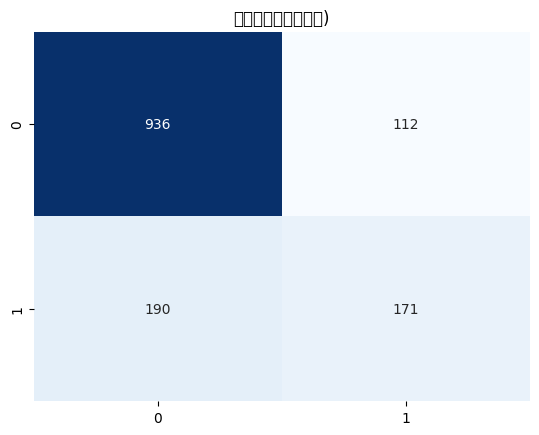

In [53]:
show_matrix(y_test, y_pred_logreg,label='混淆矩阵（逻辑回归)') # 逻辑回归

#### 分类报告

In [54]:
from sklearn.metrics import classification_report # 导入分类报告
def show_report(X_test, y_test, y_pred): # 定义一个函数显示分类报告
    # print (y_pred)
    #np.set_printoptions(threshold=np.inf)
    # print (np.where(predictions > 0.5, 0, predictions))
#     if y_test.shape != (2000,1):
#         y_test = y_test.values # 把Panda series转换成Numpy array
#         y_test = y_test.reshape((len(y_test),1)) # 转换成与y_pred相同的形状 
    #target_names = [str(x) for x in lb.classes_]
    print(classification_report(y_test,y_pred,labels=[0, 1])) #打印分类报告  

In [55]:
show_report(X_test, y_test, y_pred_logreg)

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1048
           1       0.60      0.47      0.53       361

    accuracy                           0.79      1409
   macro avg       0.72      0.68      0.70      1409
weighted avg       0.77      0.79      0.78      1409



### 神经网络模型

In [56]:
#!pip install keras
#!pip install tensorflow

In [57]:
import keras # 导入Keras库
from keras.models import Sequential # 导入Keras序贯模型
from keras.layers import Dense # 导入Keras密集连接层
dnn = Sequential() # 创建一个序贯DNN模型
dnn.add(Dense(units=12, input_dim=17, activation = 'relu')) # 添加输入层
dnn.add(Dense(units=24, activation = 'relu')) # 添加隐层
dnn.add(Dense(units=1, activation = 'sigmoid')) # 添加输出层
dnn.summary() # 显示网络模型（这个语句不是必须的）
# 编译神经网络，指定优化器，损失函数，以及评估标准
dnn.compile(optimizer = 'RMSProp', loss = 'binary_crossentropy', metrics = ['acc'])

C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 12)                  │             216 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 24)                  │             312 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              25 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 553 (2.16 KB)

 Trainable params: 553 (2.16 KB)

 Non-trainable params: 0 (0.00 B)

In [58]:
X_train.shape

(5634, 17)

In [59]:
X_train = np.asarray(X_train).astype(np.float32)
X_test = np.asarray(X_test).astype(np.float32)

In [60]:
history = dnn.fit(X_train, y_train, # 指定训练集
                  epochs=30,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_split=0.2) #这里直接从训练集数据中拆分验证集，更方便

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - acc: 0.7061 - loss: 7.9708 - val_acc: 0.7542 - val_loss: 0.9307
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.6872 - loss: 0.7980 - val_acc: 0.7870 - val_loss: 0.5936
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7018 - loss: 0.6920 - val_acc: 0.7507 - val_loss: 0.4585
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7203 - loss: 0.6470 - val_acc: 0.7924 - val_loss: 0.4798
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7220 - loss: 0.6436 - val_acc: 0.7897 - val_loss: 0.4365
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7433 - loss: 0.6091 - val_acc: 0.7879 - val_loss: 0.4463
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7473 - loss: 0.6245 - val_acc: 0.7853 - val_loss: 0.5102
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7484 - loss: 0.6291 - val_acc: 0.7897 - val_loss: 0.4785
Epoch 9/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7581 - loss:

In [61]:
def show_history(history): # 显示训练过程中的学习曲线
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(loss) + 1)
    plt.figure(figsize=(12,4))
    plt.subplot(1, 2, 1)
    plt.plot(epochs, loss, 'bo', label='Training loss')
    plt.plot(epochs, val_loss, 'b', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    acc = history.history['acc']
    val_acc = history.history['val_acc']
    plt.subplot(1, 2, 2)
    plt.plot(epochs, acc, 'bo', label='Training acc')
    plt.plot(epochs, val_acc, 'b', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show() 

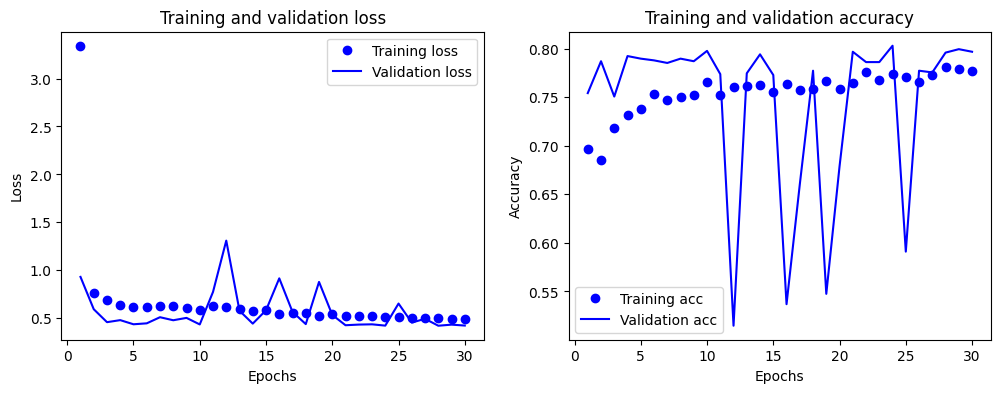

In [62]:
show_history(history) # 调用这个函数

In [63]:
result = dnn.evaluate(X_test, y_test) #评估测试集上的准确率
print('DNN的测试准确率为',"{0:.2f}%".format(result[1]))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7754 - loss: 0.4821
DNN的测试准确率为 0.78%


In [64]:
prediction = dnn.predict(X_test) #预测测试集的图片分类
print('第一个用户分类结果为:', np.argmax(prediction[0]))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
第一个用户分类结果为: 0


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing f

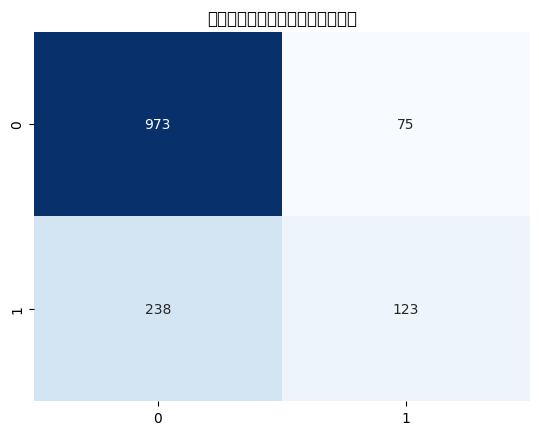

In [65]:
y_pred = dnn.predict(X_test,batch_size=10) # 预测测试集的标签
y_pred_dnn = np.round(y_pred) # 将分类概率值转换成0/1整数值
show_matrix(y_test, y_pred_dnn, label='混淆矩阵（神经网络归一化之前）') # 混淆矩阵（神经网络归一化之前）

In [66]:
show_report(X_test, y_test, y_pred_dnn)

              precision    recall  f1-score   support

           0       0.80      0.93      0.86      1048
           1       0.62      0.34      0.44       361

    accuracy                           0.78      1409
   macro avg       0.71      0.63      0.65      1409
weighted avg       0.76      0.78      0.75      1409



### 神经网络模型-归一化之后

In [67]:
from sklearn.preprocessing import MinMaxScaler #导入归一化缩放器
scaler = MinMaxScaler() #创建归一化缩放器
X_train_minmax = scaler.fit_transform(X_train) #拟合并转换训练集数据
X_test_minmax = scaler.transform(X_test) #转换测试集数据

Epoch 1/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - acc: 0.7285 - loss: 0.5482 - val_acc: 0.7365 - val_loss: 0.5006
Epoch 2/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7548 - loss: 0.4851 - val_acc: 0.7587 - val_loss: 0.4744
Epoch 3/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7673 - loss: 0.4767 - val_acc: 0.7622 - val_loss: 0.4599
Epoch 4/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7744 - loss: 0.4575 - val_acc: 0.7684 - val_loss: 0.4546
Epoch 5/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7601 - loss: 0.4663 - val_acc: 0.7782 - val_loss: 0.4483
Epoch 6/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7861 - loss: 0.4375 - val_acc: 0.7844 - val_loss: 0.4417
Epoch 7/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - acc: 0.7910 - loss: 0.4347 - val_acc: 0.7870 - val_loss: 0.4377
Epoch 8/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7895 - loss: 0.4333 - val_acc: 0.7862 - val_loss: 0.4348
Epoch 9/30
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - acc: 0.7913 - loss:

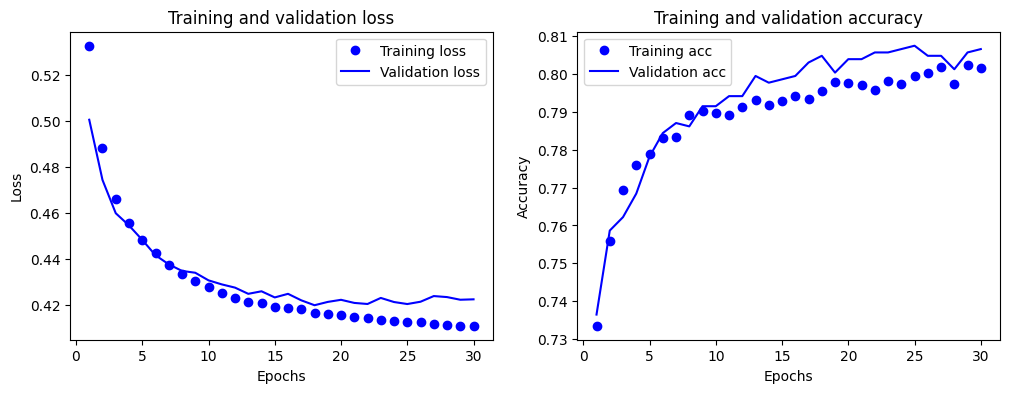

In [68]:
history = dnn.fit(X_train_minmax, y_train, # 指定训练集
                  epochs=30,        # 指定训练的轮次
                  batch_size=64,    # 指定数据批量
                  validation_split=0.2) #指定验证集,这里为了简化模型，直接用训练集数据
show_history(history) # 调用这个函数

In [69]:
result = dnn.evaluate(X_test_minmax, y_test) #评估测试集上的准确率
print('DNN（归一化之后）的测试准确率为',"{0:.2f}%".format(result[1]))

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - acc: 0.7786 - loss: 0.4576
DNN（归一化之后）的测试准确率为 0.78%


141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28151 (\N{CJK UNIFIED IDEOGRAPH-6DF7}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 28102 (\N{CJK UNIFIED IDEOGRAPH-6DC6}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 30697 (\N{CJK UNIFIED IDEOGRAPH-77E9}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 38453 (\N{CJK UNIFIED IDEOGRAPH-9635}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing f

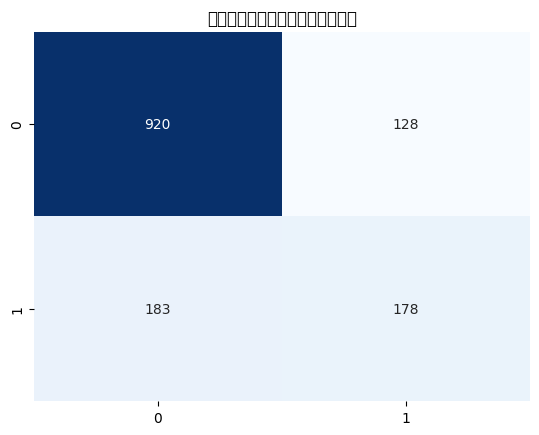

In [70]:
y_pred = dnn.predict(X_test_minmax,batch_size=10) # 预测测试集的标签
y_pred_dnn_scale = np.round(y_pred) # 将分类概率值转换成0/1整数值
show_matrix(y_test, y_pred_dnn_scale, label='混淆矩阵（神经网络归一化之后）') # 混淆矩阵（神经网络归一化之后）

In [71]:
show_report(X_test_minmax, y_test, y_pred_dnn_scale)

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1048
           1       0.58      0.49      0.53       361

    accuracy                           0.78      1409
   macro avg       0.71      0.69      0.69      1409
weighted avg       0.77      0.78      0.77      1409



#### ROC曲线和AUC

In [72]:
from sklearn.metrics import roc_curve
from sklearn.metrics import auc

In [73]:
y_pred_logreg = logreg.predict_proba(X_test)[:, 1]
fpr_logreg, tpr_logreg, thresholds_logreg = roc_curve(y_test, y_pred_logreg)
auc_logreg = auc(fpr_logreg, tpr_logreg)

C:\Users\rossliao\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [76]:
y_pred_dnn = dnn.predict(X_test).ravel()
fpr_dnn, tpr_dnn, thresholds_dnn = roc_curve(y_test, y_pred_dnn)
auc_dnn = auc(fpr_dnn, tpr_dnn)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [74]:
y_pred_dnn_scale = dnn.predict(X_test_minmax).ravel()
fpr_dnn_scale, tpr_dnn_scale, thresholds_dnn_scale = roc_curve(y_test, y_pred_dnn_scale)
auc_dnn_scale = auc(fpr_dnn_scale, tpr_dnn_scale)

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


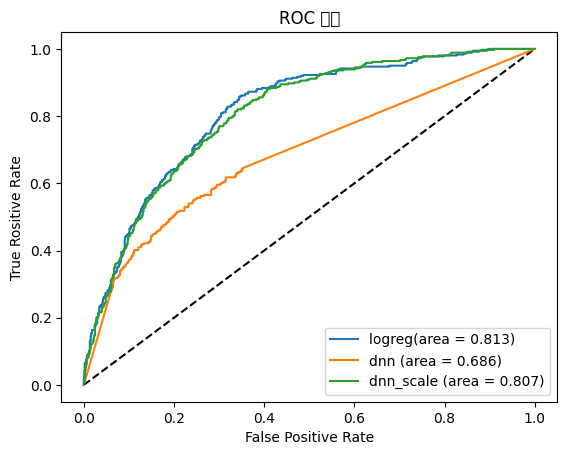

In [78]:
plt.plot([0, 1], [0, 1], 'k--')
plt.plot(fpr_logreg, tpr_logreg, label='logreg(area = {:.3f})'.format(auc_logreg))
plt.plot(fpr_dnn, tpr_dnn, label='dnn (area = {:.3f})'.format(auc_dnn))
plt.plot(fpr_dnn_scale, tpr_dnn_scale, label='dnn_scale (area = {:.3f})'.format(auc_dnn_scale))
plt.xlabel('False Positive Rate')
plt.ylabel('True Rositive Rate')
plt.title('ROC 曲线')
plt.legend(loc='best')
plt.show()